Broken: 747
Chipped: 1134
Scratched: 1367
Severe_Rust: 1205
Tip_Wear: 907


Text(0.5, 1.0, 'Data distribution before augmentation')

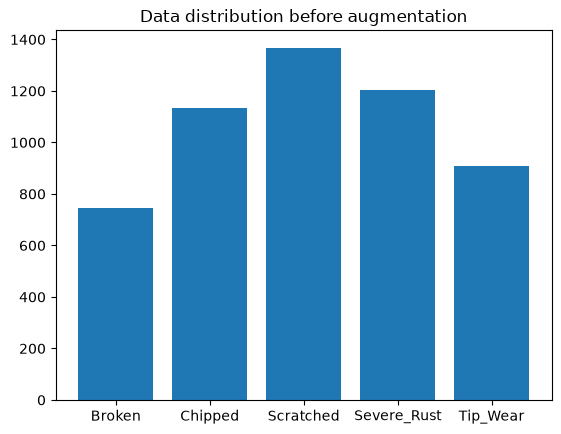

In [2]:
import glob
from typing import Counter
import os
import matplotlib.pyplot as plt

def get_class_distribution(label_images):
    count = Counter()
    label_files = glob.glob(os.path.join(label_images, "*.txt"))
    
    for label in label_files:
        if os.path.basename(label).startswith("aug"):
            continue
        with open(label, "r") as f:
            for line in f:
                parts = line.strip().split()
                count[int(parts[0])] += 1
    return count

label_path = "/Users/mac/Detect_Drill_Bit/final-dataset_test/train/labels"
count_before = get_class_distribution(label_path)
classes = ['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
target_classes = [0, 1, 2, 3, 4] # Augment all classes

for idx, name in enumerate(classes):
    print(f"{name}: {count_before[idx]}")

plt.bar(classes, [count_before[i] for i in range(5)])
plt.title("Data distribution before augmentation")

In [19]:
import cv2
def crop_rois(target_classes, label_path, img_direc):
    rois = {c: [] for c in target_classes}
    label_files = glob.glob(os.path.join(label_path, "*.txt"))

    for file in label_files:
        if os.path.basename(file).startswith("aug"):
            continue
        img_name = os.path.basename(file).replace(".txt", ".jpg")
        img_path = os.path.join(img_direc, img_name)
        if not os.path.exists(img_path):
            img_name = img_name.replace(".jpg", ".png")
            img_path = os.path.join(img_direc, img_name)
            if not os.path.exists(img_path):
                continue
        img = cv2.imread(img_path)
        h_img, w_img = img.shape[:2]

        with open(file, "r") as f:
            for line in f:
                parts = line.strip().split()
                cls_id = parts[0]
                xc, yc, w, h = map(float, parts[1:])
                
                x1 = int((xc - w/2) * w_img)
                y1 = int((yc - h/2) * h_img)
                x2 = int((xc + w/2) * w_img)
                y2 = int((yc + h/2) * h_img)

                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(x2, w_img)
                y2 = min(y2, h_img)
                
                if (x2 - x1) > 2 and (y2 - y1) > 2:
                    roi = img[y1:y2, x1:x2].copy()
                    rois[int(cls_id)].append(
                        {
                            "roi": roi,
                            "w_rel": w,
                            "h_rel": h
                        }
                    )
    return rois

img_path = "/Users/mac/Detect_Drill_Bit/final-dataset_test/train/images"
rois = crop_rois(target_classes, label_path, img_path)
for c in target_classes:
    print(f"{len(rois[c])} is {classes[c]}")

747 is Broken
1134 is Chipped
1367 is Scratched
1205 is Severe_Rust
907 is Tip_Wear
